## PROGETTO D'ESAME PYTHON DI RICCARDO PARISI

## Traccia dell'esame:
Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. In particolare, il dataset si può scaricare dalla piattaforma o dall’indirizzo https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
url = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)

Dopo aver **importato Pandas** per leggere e manipolare il Dataset, **importato MatPlot** per i grafici e **Seaborn** per avere le interfacce grafiche, Carico il dataset direttamente dal file CSV ufficiale di Our World in Data usando **"pd.read_csv()"** così ottengo un DataFrame su cui fare analisi e visualizzazioni

## **1- Si richiede di verificare le dimensioni del dataset e i relativi metadati**

Ora faccio un **EDA iniziale:** 

In [4]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


**.head mostra le prime 5 righe del dataset** e mi aiuta ad avere una prima idea su ciò che abbiamo :

-   nomi delle colonne
-   tipo di contenuto
-   formato delle date
-   presenza iniziale di valori nulli

Ora valuto **le dimensioni** del Dataset: 

In [5]:
df.shape

(429435, 67)

Uso **.shape** per verificare la **dimensione del dataset**, cioè quante righe e colonne contiene.


Ora uso **df.info()** perché mi aiuta a vedere:

-   nome delle colonne
-   quanti valori non nulli ci sono
-   tipo di dato di ogni colonna

 **(metadati)**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

In [7]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

Con **df.columns** posso vedere tutti i nomi delle colonne.

Utilizzerò **df.describe()**  perché mi **fa vedere le statistiche delle colonne numeriche**:
-   count
-   mean
-   std
-   min
-   quartili
-   max
  
Così posso capire a primo sguardo se ci sono:
-   numeri molto grandi
-   anomalie
-   distribuzioni molto sbilanciate

In [8]:
df.describe()

,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,411804.000000,410159.000000,408929.000000,411804.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
mean,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060828,112096.199420,122.357073,122.713852,835.514337,...,33.097758,50.649390,3.106895,73.702098,0.722178,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666404
std,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636565,162240.412405,1508.778585,559.701663,1134.932641,...,13.853952,31.905236,2.549168,7.387914,0.149237,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892770
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,1.190000,0.100000,53.280000,0.390000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.450000
25%,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,1916.100000,0.000000,0.000000,24.570000,...,22.600000,20.860000,1.300000,69.500000,0.600000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.875000
50%,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,29145.480000,0.000000,2.790000,295.090000,...,33.100000,49.540000,2.500000,75.050000,0.740000,6.336393e+06,6.815200e+03,8.130000,5.660000,1270.800000
75%,7.582720e+05,0.000000e+00,3.132900e+02,9.574000e+03,0.000000,3.140000,156770.190000,0.000000,56.250000,1283.820000,...,41.500000,82.500000,4.210000,79.460000,0.830000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.025000
max,7.758668e+08,4.423623e+07,6.319461e+06,7.057132e+06,103719.000000,14817.000000,763598.600000,241758.230000,34536.890000,6601.110000,...,78.100000,100.000000,13.800000,86.750000,0.960000,7.975105e+09,1.349776e+06,78.080000,378.220000,10293.520000


## 2. Si chiede di trovare, per ogni continente:
## a. il numero di casi fin dall'inizio della pandemia


In [9]:
df["continent"].unique()

array(['Asia', nan, 'Europe', 'Africa', 'Oceania', 'North America',
       'South America'], dtype=object)

In [10]:
df["location"].unique()[:20]

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'American Samoa',
       'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda',
       'Argentina', 'Armenia', 'Aruba', 'Asia', 'Australia', 'Austria',
       'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados'],
      dtype=object)

- Utilizzo df["continent"]**.unique()** per **vedere** i continenti presenti e anche eventuali **NaN**
- df["location"]**.unique()[:20]** per vedere i primi 20 valori distinti della colonna "location" per capire se ci siano solo noimi dei paesi. 

Converto la colonna **"date"** in formato ***datetime*** per poter fare filtri temporali, per permettermi così di ordinare cronologicamente, fare grafici temporali corretti, filtrare per anno o per intervalli di date.

In [11]:
df["date"] = pd.to_datetime(df["date"])

Ora **filtro** il dataset **rimuovendo** i **valori nulli** nella colonna **"continent"** per escludere dati aggregati come Europe e altri dati globali non conformi dalle richieste della traccia e mantengo solo i paesi.

In [12]:
df_clean = df[df["continent"].notna()]

In [13]:
df_clean.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [14]:
df_clean.shape

(402910, 67)

> Per ogni continente, **calcolo** il **numero totale** di casi utilizzando la funzione **"groupby"** e prendendo il **valore massimo** (con **.max** che mi restituisce il valore finale ultimo disponibile) della colonna **"total cases"**, in quanto i dati sono cumulativi nel tempo.

In [15]:
casi_continente = df_clean.groupby("continent")["total_cases"].max()
casi_continente

continent
Africa             4072765.0
Asia              99373219.0
Europe            38997490.0
North America    103436829.0
Oceania           11861161.0
South America     37511921.0
Name: total_cases, dtype: float64

## b. la percentuale rispetto al totale mondiale del numero di casi

**Riutilizzo** il dataset iniziale **"df"** e **non** più quello filtrato **"df-clean"** perché ora ci serve il totale mondiale che possiamo ritrovare su **"world"**, quindi riutilizzo il **".max()"** per trovare il totale finale. 

In [16]:
totale_mondiale = df[df["location"] == "World"]["total_cases"].max()
totale_mondiale

775866783.0

Ora faccio la **percentuale** per continente:

In [17]:
percentuali = (casi_continente / totale_mondiale) * 100
percentuali

continent
Africa            0.524931
Asia             12.808026
Europe            5.026313
North America    13.331777
Oceania           1.528763
South America     4.834840
Name: total_cases, dtype: float64

E **arrotondo** grazie al metodo **".round()"** per avere i dati più puliti possibile:

In [18]:
percentuali = percentuali.round(2)
percentuali

continent
Africa            0.52
Asia             12.81
Europe            5.03
North America    13.33
Oceania           1.53
South America     4.83
Name: total_cases, dtype: float64

Ho **calcolato** così la **percentuale** dei casi per continente rispetto al totale mondiale

Ora **creo** un **DataFrame finale** per **unire** in un’unica struttura i **casi totali** e le **percentuali per continente**, rendendo il risultato più leggibile e interpretabile.

In [19]:
risultato = pd.DataFrame({
    "casi_totali": casi_continente,
    "percentuale": percentuali
})

risultato

,casi_totali,percentuale
continent,,
Africa,4072765.0,0.52
Asia,99373219.0,12.81
Europe,38997490.0,5.03
North America,103436829.0,13.33
Oceania,11861161.0,1.53
South America,37511921.0,4.83


## 3. Selezionare i dati relativi all'Italia nel 2022 e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni; quindi mostrare con dei grafici adeguati:

**Filtro** prendendo **SOLO** i dati dell’***Italia***

In [20]:
df_italia = df[df["location"] == "Italy"]
df_italia.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
185275,ITA,Europe,Italy,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,-1904.1,-12.37,-12.37,-32.0
185276,ITA,Europe,Italy,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
185277,ITA,Europe,Italy,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
185278,ITA,Europe,Italy,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
185279,ITA,Europe,Italy,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN


E **filtro** per l'anno **2022** come richiesto dalla traccia utilizzando **.dt.year** che prende l’anno dalla data

In [21]:
df_italia_2022 = df_italia[df_italia["date"].dt.year == 2022]
df_italia_2022.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
186002,ITA,Europe,Italy,2022-01-01,5622431.0,0.0,36797.00,136530.0,0.0,140.86,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186003,ITA,Europe,Italy,2022-01-02,6267035.0,644604.0,92086.29,137513.0,983.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,168226.3,12.99,8.06,2849.48
186004,ITA,Europe,Italy,2022-01-03,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186005,ITA,Europe,Italy,2022-01-04,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN
186006,ITA,Europe,Italy,2022-01-05,6267035.0,0.0,92086.29,137513.0,0.0,140.43,...,27.8,NaN,3.18,83.51,0.89,59037472,NaN,NaN,NaN,NaN


**Rimuovo** le **righe** in cui la colonna **"new_cases"** aveva **valori nulli**, così da **mantenere** solo i giorni con una misurazione disponibile per i nuovi casi.

In [22]:
df_italia_2022 = df_italia_2022[df_italia_2022["new_cases"].notna()]

E **controllo** se mi ha **restituito 0**

Ora **utilizzo** il metodo **".plot"** di Pandas per visualizzare l’***andamento temporale dei casi totali*** e dei ***nuovi casi*** in Italia nel 2022 risolvendo così sia il punto A che B del punto 2 della traccia d'esame

In [26]:
df_italia_2022["new_cases"].isna().sum()

np.int64(0)

<Axes: title={'center': 'Casi totali Italia 2022'}, xlabel='date'>

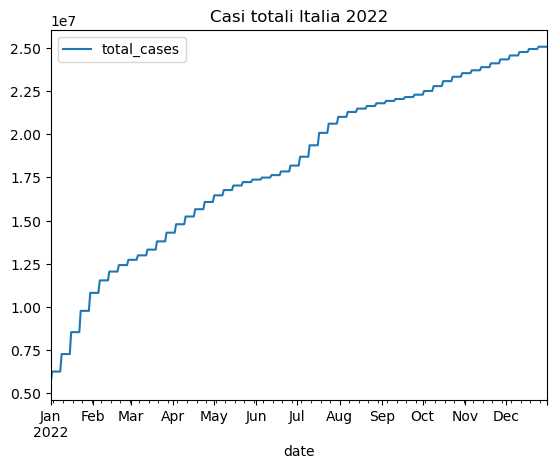

In [27]:
df_italia_2022.plot(x="date", y="total_cases", title="Casi totali Italia 2022")

<Axes: title={'center': 'Nuovi casi Italia 2022'}, xlabel='date'>

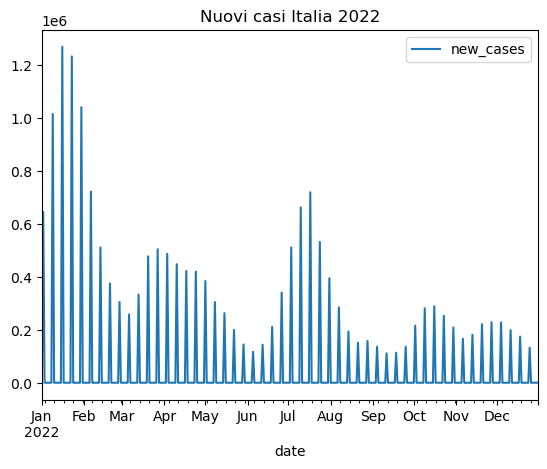

In [28]:
df_italia_2022.plot(x="date", y="new_cases", title="Nuovi casi Italia 2022")

## 4. Riguardo le nazioni di Italia, Germania e Francia: mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso)

**Filtro** i paesi con **".isin"** che permette di darmi solo le righe dove la location è Italy, Germany o France:

In [30]:
paesi = ["Italy", "Germany", "France"]
df_paesi = df[df["location"].isin(paesi)]

E ne **filtro** il **periodo**:

In [31]:
df_periodo = df_paesi[
    (df_paesi["date"] >= "2022-05-01") &
    (df_paesi["date"] <= "2023-04-30")
]

**Rimuovo** i **NaN**:

In [32]:
df_periodo = df_periodo[df_periodo["icu_patients"].notna()]

Mostro il **Boxplot**: 

<Axes: xlabel='location', ylabel='icu_patients'>

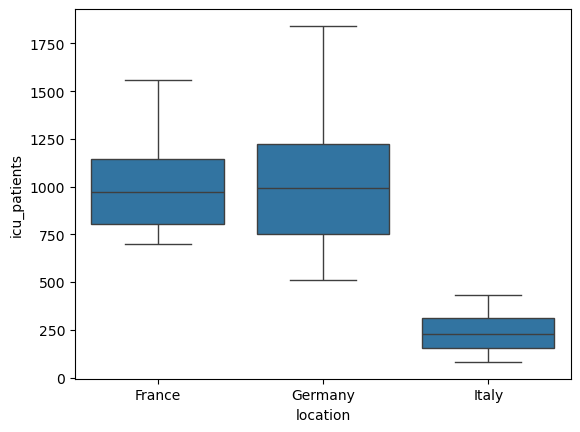

In [35]:
import seaborn as sns

sns.boxplot(data=df_periodo, x="location", y="icu_patients")

## 4-b. scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante

Dal boxplot possiamo vedere differenze tra i tre paesi nel numero di pazienti in terapia intensiva. Paesi come Germania e Spagna mostrano una maggiore variabilità e valori più elevati rispetto all'Italia, dandoci così conferma di un impatto diverso della pandemia fra i vari paesi, nel periodo richiesto.

## 5- Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
### a - mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)

**filtro** i paesi:

In [36]:
paesi = ["Italy", "Germany", "France", "Spain"]
df_paesi = df[df["location"].isin(paesi)]

**filtro** per anno 2021:

In [37]:
df_2021 = df_paesi[df_paesi["date"].dt.year == 2021]

**Rimuovo** i dati **NaN** e controllo i dati:

In [43]:
df_2021 = df_2021[df_2021["hosp_patients"].notna()]

In [44]:
df_2021["location"].value_counts()

location
France    365
Italy     365
Spain     365
Name: count, dtype: int64

**Uso** il **".groupby"** per raggruppare e il **".sum"** per sommare i dati ed avere il **totale per paese**:

In [45]:
somma_pazienti = df_2021.groupby("location")["hosp_patients"].sum()

E mostro sia **graficamente** che **numericamente** i dati:

In [46]:
somma_pazienti

location
France    6008717.0
Italy     4419950.0
Spain     2411706.0
Name: hosp_patients, dtype: float64

<Axes: xlabel='location'>

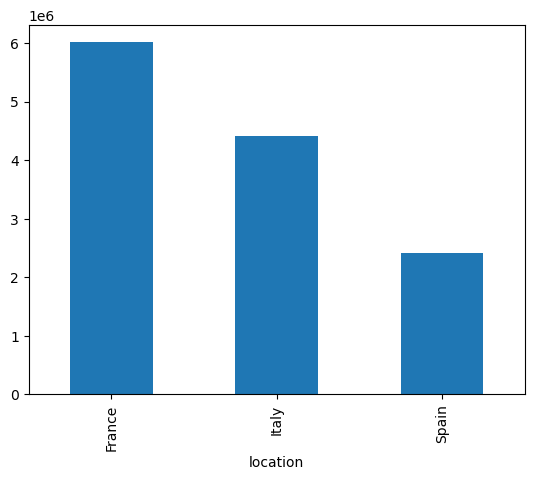

In [47]:
somma_pazienti.plot(kind="bar")

Dal grafico emerge che ***Francia e Italia*** hanno registrato un ***numero totale di pazienti ospedalizzati*** significativamente **più elevato** rispetto alla ***Spagna*** nel corso del **2021**. La ***Germania*** *non è rappresentata*, probabilmente a causa dell’**assenza di dati** nella colonna "hosp_patients"

### b - se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno

Controllo i **nulli** in **"hosp_patiens"**:

In [49]:
df_paesi_2021 = df_paesi[df_paesi["date"].dt.year == 2021]

df_paesi_2021["hosp_patients"].isna().sum()

np.int64(365)

Questo ci dice **quanti NaN ci sono in totale** nel sottoinsieme già filtrato.

### Conclusione:

Sono presenti ***numerosi valori nulli*** (365), probabilmente dovuti all’assenza di dati per uno dei paesi che, a primo occhio è la **Germania**. Per come ho ragionato, non è consigliabile sostituirli, poiché si tratta di ***dati temporali sensibili***; è preferibile ***escluderli*** direttamente dall’analisi.